# KV Cache Comparison — MHA vs MQA vs GQA vs MLA

For a single sequence at length `t`, the KV cache size per layer is:

| Method | Cache size per token (values) |
|--------|-------------------------------|
| MHA    | `2 × n_heads × d_head` |
| MQA    | `2 × 1 × d_head` |
| GQA    | `2 × n_kv_heads × d_head` |
| MLA    | `d_c` |

This notebook computes and plots these for realistic LLM configurations.

**No exercises here.** Run top to bottom.

## Setup

In [1]:
import matplotlib.pyplot as plt

## 1. Cache size per token (Llama 3 70B-style config)

Use: `n_heads = 64`, `d_head = 128`. Compare MHA, MQA, GQA(8 groups), MLA(d_c=512).

method                 values/token
------------------------------------
MHA                           16384
MQA                             256
GQA (8 groups)                 2048
MLA (d_c=512)                   512


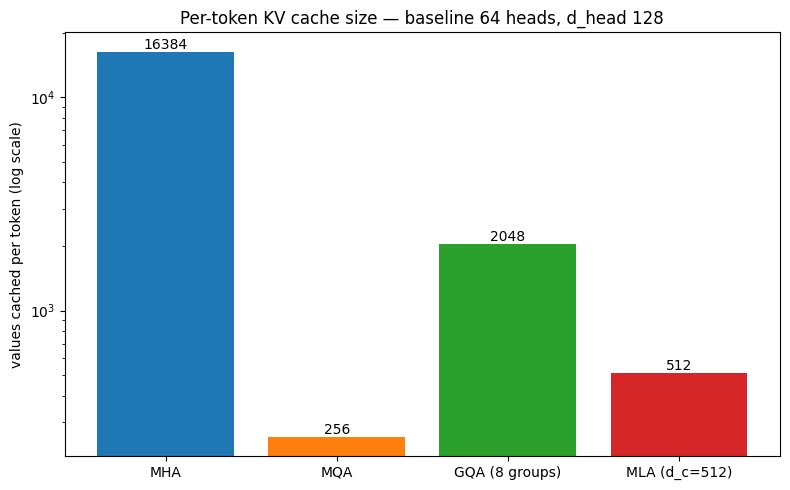

In [2]:
n_heads, d_head = 64, 128
methods = {
    'MHA':            2 * n_heads * d_head,   # 16384
    'MQA':            2 * 1       * d_head,   # 256
    'GQA (8 groups)': 2 * 8       * d_head,   # 2048
    'MLA (d_c=512)':  512,
}

print(f"{'method':<20} {'values/token':>14}")
print('-' * 36)
for name, v in methods.items():
    print(f'{name:<20} {v:>14}')

fig, ax = plt.subplots(figsize=(8, 5))
names = list(methods.keys())
vals  = list(methods.values())
bars = ax.bar(names, vals, color=['C0', 'C1', 'C2', 'C3'])
ax.set_yscale('log')
ax.set_ylabel('values cached per token (log scale)')
ax.set_title('Per-token KV cache size — baseline 64 heads, d_head 128')
for b, v in zip(bars, vals):
    ax.text(b.get_x() + b.get_width() / 2, v, str(v), ha='center', va='bottom')
plt.tight_layout()
plt.show()

## 2. Total cache size at varying context lengths

Multiply by sequence length and number of layers. Use `n_layers = 80`, fp16 = 2 bytes.

   seq_len               MHA               MQA    GQA (8 groups)     MLA (d_c=512)
------------------------------------------------------------------------------------
      1024             2.500             0.039             0.312             0.078
      4096            10.000             0.156             1.250             0.312
     16384            40.000             0.625             5.000             1.250
     65536           160.000             2.500            20.000             5.000
    131072           320.000             5.000            40.000            10.000


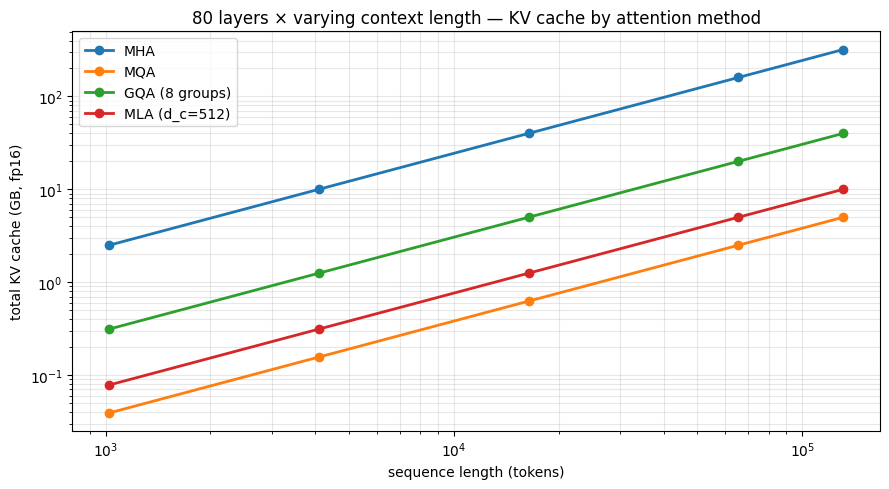

In [3]:
n_layers = 80
bytes_per_value = 2
seq_lens = [1024, 4096, 16384, 65536, 131072]

print(f"{'seq_len':>10}  " + '  '.join(f'{name:>16}' for name in methods))
print('-' * (12 + 18 * len(methods)))
for sl in seq_lens:
    row = [f'{sl:>10}']
    for vals_per_token in methods.values():
        gb = n_layers * vals_per_token * sl * bytes_per_value / (1024 ** 3)
        row.append(f'{gb:>16.3f}')
    print('  '.join(row))

fig, ax = plt.subplots(figsize=(9, 5))
for name, vals_per_token in methods.items():
    cache_gb = [
        n_layers * vals_per_token * sl * bytes_per_value / (1024 ** 3)
        for sl in seq_lens
    ]
    ax.loglog(seq_lens, cache_gb, 'o-', label=name, linewidth=2)

ax.set_xlabel('sequence length (tokens)')
ax.set_ylabel('total KV cache (GB, fp16)')
ax.set_title('80 layers × varying context length — KV cache by attention method')
ax.legend()
ax.grid(True, which='both', alpha=0.3)
plt.tight_layout()
plt.show()

## 3. Quality vs cache trade-off (illustrative)

The blog claims rough quality numbers:
- MHA: 100% (baseline)
- GQA(8): ~99.5%
- MQA: ~98-99%
- MLA: ~100% (full per-head diversity preserved)

Plot quality (y) vs cache size (x, log) — MLA dominates the Pareto frontier.

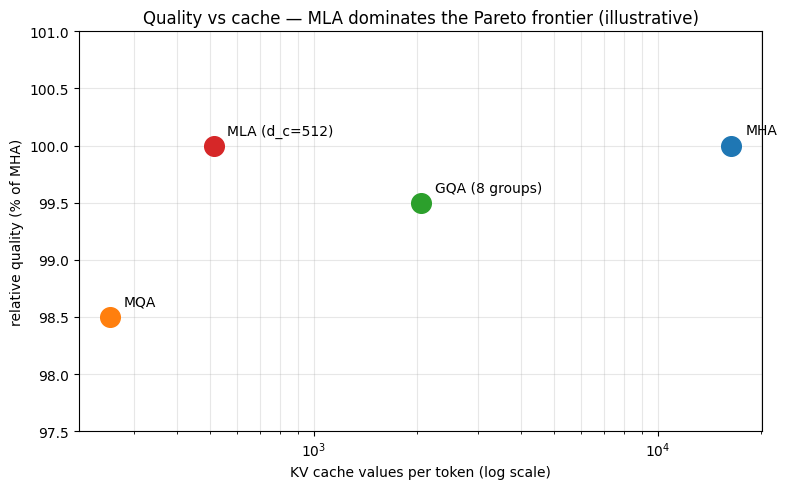

In [4]:
quality = {
    'MHA':            100.0,
    'MQA':             98.5,
    'GQA (8 groups)':  99.5,
    'MLA (d_c=512)':  100.0,
}
colors = {'MHA': 'C0', 'MQA': 'C1', 'GQA (8 groups)': 'C2', 'MLA (d_c=512)': 'C3'}

fig, ax = plt.subplots(figsize=(8, 5))
for name in quality:
    x = methods[name]
    y = quality[name]
    ax.scatter(x, y, s=200, color=colors[name], zorder=3)
    ax.annotate(name, (x, y), textcoords='offset points', xytext=(10, 8), fontsize=10)

ax.set_xscale('log')
ax.set_xlabel('KV cache values per token (log scale)')
ax.set_ylabel('relative quality (% of MHA)')
ax.set_title('Quality vs cache — MLA dominates the Pareto frontier (illustrative)')
ax.grid(True, which='both', alpha=0.3)
ax.set_ylim(97.5, 101)
plt.tight_layout()
plt.show()

## Takeaways

1. **GQA is the safe default.** Most production models picked it because the quality-vs-memory trade-off is hard to beat without engineering complexity.
2. **MLA dominates on Pareto.** Full per-head diversity at GQA-or-better memory cost — but requires custom kernels and decoupled RoPE.
3. **MQA is a relic** of a bygone era — pure MQA is rarely worth the quality hit now that GQA exists.
4. **Context length compounds the choice.** At 4K context, GQA-vs-MLA is a few hundred MB difference. At 128K context, it's tens of GB — the difference between fitting and not fitting on a GPU.